<a href="https://colab.research.google.com/github/vedant-sangrame/Machine-Learning-TAE1/blob/main/ML_TAE_1_ALL_8020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Logistic Regression Performance:
Accuracy : 0.5793628885330978
Precision: 0.5641802141882922
Recall   : 0.5793628885330978
F1 Score : 0.5413411980058629
RMSE     : 0.6498410424442151


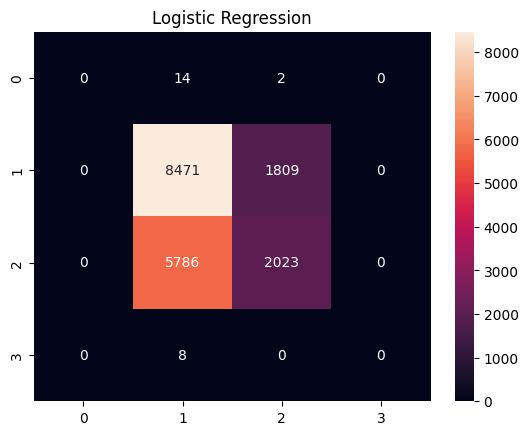


Decision Tree Performance:
Accuracy : 0.891238337105946
Precision: 0.8917964622050902
Recall   : 0.891238337105946
F1 Score : 0.8914556085208523
RMSE     : 0.3337839020369096


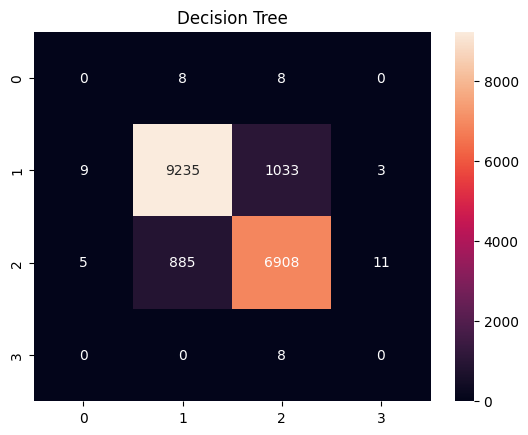

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



KNN Performance:
Accuracy : 0.6004527135206758
Precision: 0.5989427729982871
Recall   : 0.6004527135206758
F1 Score : 0.5996711072641051
RMSE     : 0.6336677435794115


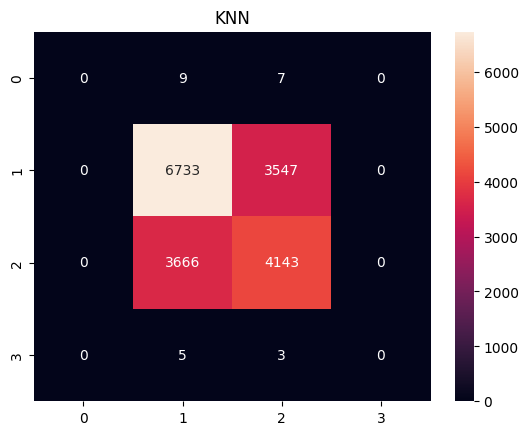


Random Forest Performance:
Accuracy : 0.8406117153425716
Precision: 0.8399509293144202
Recall   : 0.8406117153425716
F1 Score : 0.8402341155758631
RMSE     : 0.4010971537392184


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


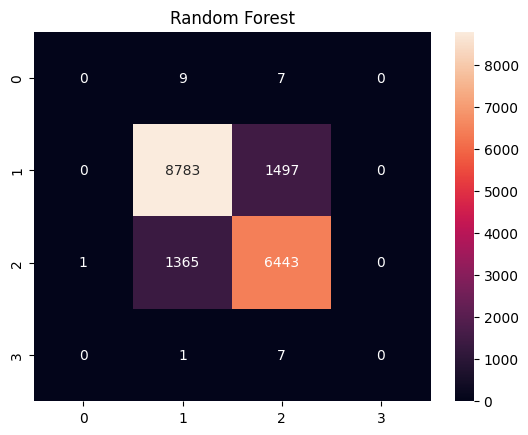


SVC Performance:
Accuracy : 0.6186716722795782
Precision: 0.6114948629628929
Recall   : 0.6186716722795782
F1 Score : 0.6082191906584785
RMSE     : 0.6185898018096382


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


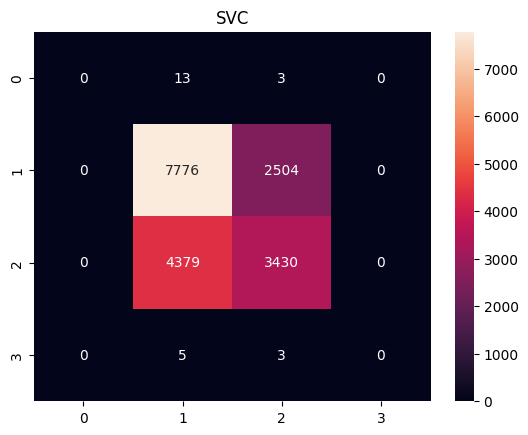


Naive Bayes Performance:
Accuracy : 0.5515375697013195
Precision: 0.5583740395788644
Recall   : 0.5515375697013195
F1 Score : 0.5531973225108394
RMSE     : 0.671279062663351


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


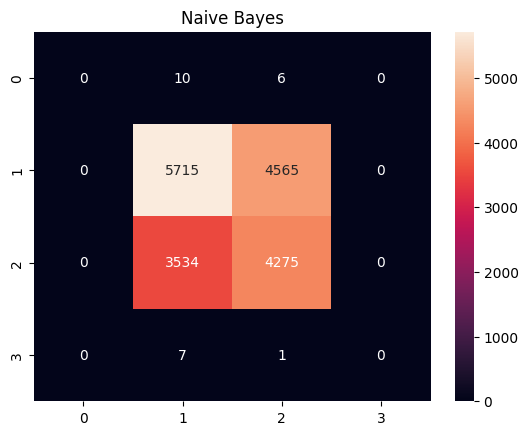



===== MODEL COMPARISON =====
                 Model  Accuracy  Precision    Recall  F1 Score      RMSE
0  Logistic Regression  0.579363   0.564180  0.579363  0.541341  0.649841
1        Decision Tree  0.891238   0.891796  0.891238  0.891456  0.333784
2                  KNN  0.600453   0.598943  0.600453  0.599671  0.633668
3        Random Forest  0.840612   0.839951  0.840612  0.840234  0.401097
4                  SVC  0.618672   0.611495  0.618672  0.608219  0.618590
5          Naive Bayes  0.551538   0.558374  0.551538  0.553197  0.671279

Best Model Based on Accuracy:
Model        Decision Tree
Accuracy          0.891238
Precision         0.891796
Recall            0.891238
F1 Score          0.891456
RMSE              0.333784
Name: 1, dtype: object


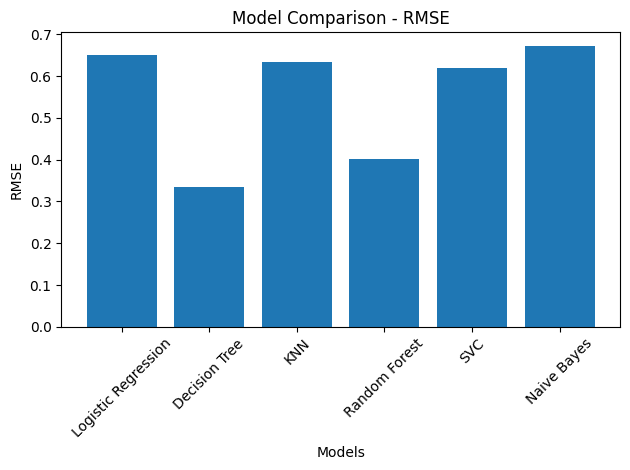

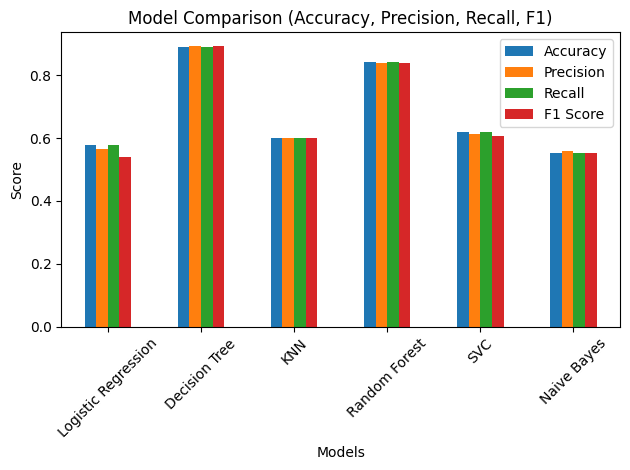

In [2]:
# ================== STEP 1: IMPORT LIBRARIES ==================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    mean_squared_error
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from google.colab import drive
drive.mount('/content/drive')

# ================== STEP 2: LOAD DATA ==================
path = "/content/drive/MyDrive/ML_dataset/US_Accidents_March23.csv"
df = pd.read_csv(path, nrows=150000)

# ================== STEP 3: DATA CLEANING ==================
df.drop_duplicates(inplace=True)

data = df[['Severity','Start_Lat','Start_Lng','Distance(mi)',
           'Temperature(F)','Humidity(%)','Pressure(in)',
           'Visibility(mi)','Wind_Speed(mph)']]

data = data.dropna()

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

# ================== STEP 4: PREPROCESSING ==================
X = data.drop('Severity', axis=1)
y = data['Severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================== STEP 5: FUNCTION ==================
results = []

def run_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Store results
    results.append([name, acc, prec, rec, f1, rmse])

    print(f"\n{name} Performance:")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print("RMSE     :", rmse)

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
    plt.title(name)
    plt.show()

# ================== STEP 6: RUN ALL MODELS ==================
run_model(LogisticRegression(max_iter=1000), "Logistic Regression")
run_model(DecisionTreeClassifier(), "Decision Tree")
run_model(KNeighborsClassifier(n_neighbors=5), "KNN")
run_model(RandomForestClassifier(n_estimators=100), "Random Forest")
run_model(SVC(), "SVC")
run_model(GaussianNB(), "Naive Bayes")

# ================== STEP 7: COMPARISON TABLE ==================
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "RMSE"
])

print("\n\n===== MODEL COMPARISON =====")
print(results_df)

# Best model (based on Accuracy)
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print("\nBest Model Based on Accuracy:")
print(best_model)

# ================== GRAPH 1: RMSE COMPARISON ==================
plt.figure()

plt.bar(results_df["Model"], results_df["RMSE"])

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ================== GRAPH 2: OVERALL MODEL COMPARISON ==================
metrics_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]

metrics_df.plot(kind='bar')

plt.title("Model Comparison (Accuracy, Precision, Recall, F1)")
plt.xlabel("Models")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()